In [1]:
!pip install sentence-transformers

   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/596.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/596.4 kB ? eta -:--:--
   -------------------------------------- 596.4/596.4 kB 737.9 kB/s eta 0:00:00


In [3]:
import pandas as pd

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

In [4]:
jobs = pd.read_csv(
    r"C:\Users\cbala\OneDrive\Desktop\RecruitSmart\data\jobs_cleaned.csv"
)

In [7]:
jobs["text"] = (
    jobs["description"].fillna("") + " " +
    jobs["requirements"].fillna("")
)

In [9]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Model Loaded Successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\cbala\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\cbala\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model Loaded Successfully!


In [11]:
sample_jobs = jobs["text"][:100]

embeddings = model.encode(
    sample_jobs.tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [13]:
print(embeddings.shape)

(100, 384)


In [15]:
bert_similarity = cosine_similarity(
    embeddings
)

print(bert_similarity.shape)

(100, 100)


In [17]:
similarity_df = pd.DataFrame(bert_similarity)

similarity_df.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,1.000000,0.315090,0.214838,0.230892,0.264780,0.305161,0.358212,0.340961,0.276586,0.332594,...,0.381811,0.316855,0.240779,0.212064,0.297907,0.482902,0.235351,0.352172,0.212785,0.119812
1,0.315090,1.000000,0.233428,0.409566,0.155119,0.357231,0.340055,0.462915,0.266112,0.334658,...,0.392175,0.392530,0.289800,0.230295,0.386470,0.517003,0.348440,0.256316,0.227593,0.284334
2,0.214838,0.233428,1.000000,0.233171,0.531060,0.410708,0.181137,0.178933,0.428223,0.508518,...,0.187225,0.353668,0.329325,0.465144,0.365643,0.364536,0.345072,0.575737,0.593403,0.162530
3,0.230892,0.409566,0.233171,1.000000,0.294031,0.464730,0.304415,0.328437,0.253554,0.394846,...,0.235185,0.352985,0.222081,0.327914,0.294355,0.412460,0.220013,0.235147,0.297815,0.221823
4,0.264780,0.155119,0.531060,0.294031,1.000000,0.476032,0.227023,0.184768,0.445174,0.562062,...,0.232535,0.340060,0.289228,0.456463,0.325899,0.349396,0.242096,0.542581,0.491012,0.164161


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=500
)

tfidf_matrix = tfidf.fit_transform(sample_jobs)

tfidf_similarity = cosine_similarity(
    tfidf_matrix
)

In [21]:
print("Average TF-IDF Similarity")

print(tfidf_similarity.mean())

Average TF-IDF Similarity
0.11881138409952899


In [23]:
print("Average TF-IDF Similarity")

print(tfidf_similarity.mean())

Average TF-IDF Similarity
0.11881138409952899


In [25]:
print("Average BERT Similarity")

print(bert_similarity.mean())

Average BERT Similarity
0.32899314


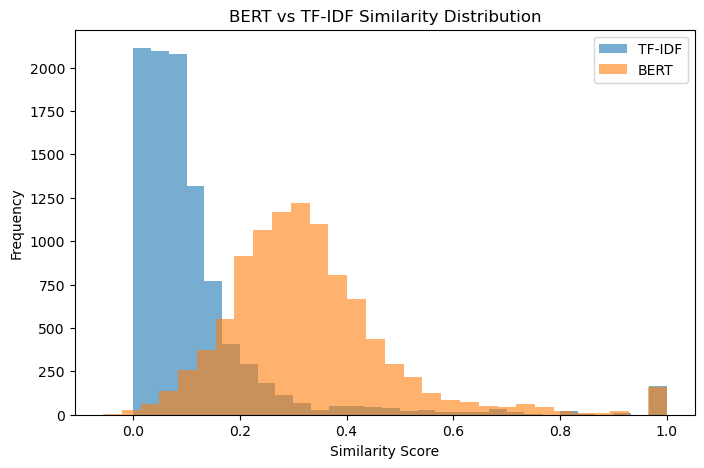

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    tfidf_similarity.flatten(),
    bins=30,
    alpha=0.6,
    label="TF-IDF"
)

plt.hist(
    bert_similarity.flatten(),
    bins=30,
    alpha=0.6,
    label="BERT"
)

plt.legend()

plt.title("BERT vs TF-IDF Similarity Distribution")

plt.xlabel("Similarity Score")

plt.ylabel("Frequency")

plt.show()

In [29]:
embedding_df = pd.DataFrame(embeddings)

embedding_df.to_csv(
    r"C:\Users\cbala\OneDrive\Desktop\RecruitSmart\bert_embeddings.csv",
    index=False
)

print("Embeddings Saved Successfully!")

Embeddings Saved Successfully!
